In [1]:
import os

os.getcwd()

'/Users/monicachaganti/Desktop/ML models for Earth observation'

In [2]:
os.listdir()

['Sentinal-2',
 '.DS_Store',
 'EuroSat',
 'ML models for earth observation.ipynb',
 '.ipynb_checkpoints']

In [3]:
base_path = "/Users/monicachaganti/Desktop/ML models for Earth observation"

In [4]:
import os

os.listdir(base_path)

['Sentinal-2',
 '.DS_Store',
 'EuroSat',
 'ML models for earth observation.ipynb',
 '.ipynb_checkpoints']

In [5]:
eurosat_path = base_path + "/EuroSat"
sentinel_path = base_path + "/Sentinal-2"

In [6]:
print(os.listdir(eurosat_path))
print(os.listdir(sentinel_path))

['.DS_Store', 'EuroSAT', 'EuroSATallBands']
['sentinel_2', '.DS_Store', 'EuroSAT']


In [7]:
!pip install torch torchvision

In [8]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [9]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.2.2
0.17.2


In [10]:
import os
from torchvision import datasets, transforms

eurosat_path = "/Users/monicachaganti/Desktop/ML models for Earth observation/EuroSat"

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

eurosat_dataset = datasets.ImageFolder(
    root=eurosat_path,
    transform=transform
)

print("Dataset size:", len(eurosat_dataset))
print("Classes:", eurosat_dataset.classes)

Dataset size: 54597
Classes: ['EuroSAT', 'EuroSATallBands']


In [11]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root=eurosat_path,
    transform=transform
)

In [12]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN(num_classes=len(eurosat_dataset.classes))
model.to(device)

print(device)

cpu


In [14]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [15]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root=eurosat_path,
    transform=transform
)

In [16]:
eurosat_path = "/Users/monicachaganti/Desktop/ML models for Earth observation/EuroSat/EuroSAT"

In [17]:
import os

for item in os.listdir(eurosat_path):
    print(item)

Forest
validation.csv
River
.DS_Store
Highway
AnnualCrop
test.csv
SeaLake
label_map.json
HerbaceousVegetation
Industrial
Residential
PermanentCrop
Pasture
train.csv


In [18]:
for root, dirs, files in os.walk(eurosat_path):
    print("ROOT:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    print("-"*50)
    break

ROOT: /Users/monicachaganti/Desktop/ML models for Earth observation/EuroSat/EuroSAT
DIRS: ['Forest', 'River', 'Highway', 'AnnualCrop', 'SeaLake']
FILES: ['validation.csv', '.DS_Store', 'test.csv', 'label_map.json', 'train.csv']
--------------------------------------------------


In [19]:
import os

print(os.listdir(eurosat_path))

['Forest', 'validation.csv', 'River', '.DS_Store', 'Highway', 'AnnualCrop', 'test.csv', 'SeaLake', 'label_map.json', 'HerbaceousVegetation', 'Industrial', 'Residential', 'PermanentCrop', 'Pasture', 'train.csv']


In [20]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root=eurosat_path,
    transform=transform
)

print("Dataset size:", len(dataset))
print("Classes:", dataset.classes)

Dataset size: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [21]:
from torch.utils.data import DataLoader, random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  
        x = self.pool(F.relu(self.conv2(x)))  
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN(num_classes=len(dataset.classes)).to(device)

print(device)

cpu


In [24]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 2.3030
Epoch 2, Loss: 2.3030
Epoch 3, Loss: 2.3030
Epoch 4, Loss: 2.3030
Epoch 5, Loss: 2.3030


In [25]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 9.351851851851851


In [26]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [27]:
dataset = datasets.ImageFolder(
    root=eurosat_path,
    transform=transform
)

In [28]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [29]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)  

epochs = 10

In [30]:
for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 1.0293
Epoch 2, Loss: 0.6235
Epoch 3, Loss: 0.5131
Epoch 4, Loss: 0.4322
Epoch 5, Loss: 0.3635
Epoch 6, Loss: 0.3061
Epoch 7, Loss: 0.2614
Epoch 8, Loss: 0.2175
Epoch 9, Loss: 0.1921
Epoch 10, Loss: 0.1676


In [31]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 90.44444444444444


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[541   1   8   5   0   4  19   0   7   8]
 [  1 560   3   0   0   7   0   0   4  26]
 [  1   1 518  10   5   5  39  16  11   1]
 [  7   0   6 397  15   1  13  13  22   0]
 [  0   0   0   3 452   0   1  34   2   0]
 [  7  10  13   3   0 335   5   0   6   6]
 [ 21   0  27  14   3   5 411   2   9   0]
 [  0   0   1   3   6   0   0 597   1   0]
 [ 16   3   2  28   0  10   5   0 444   2]
 [  1   1   1   0   0   2   0   0   4 629]]


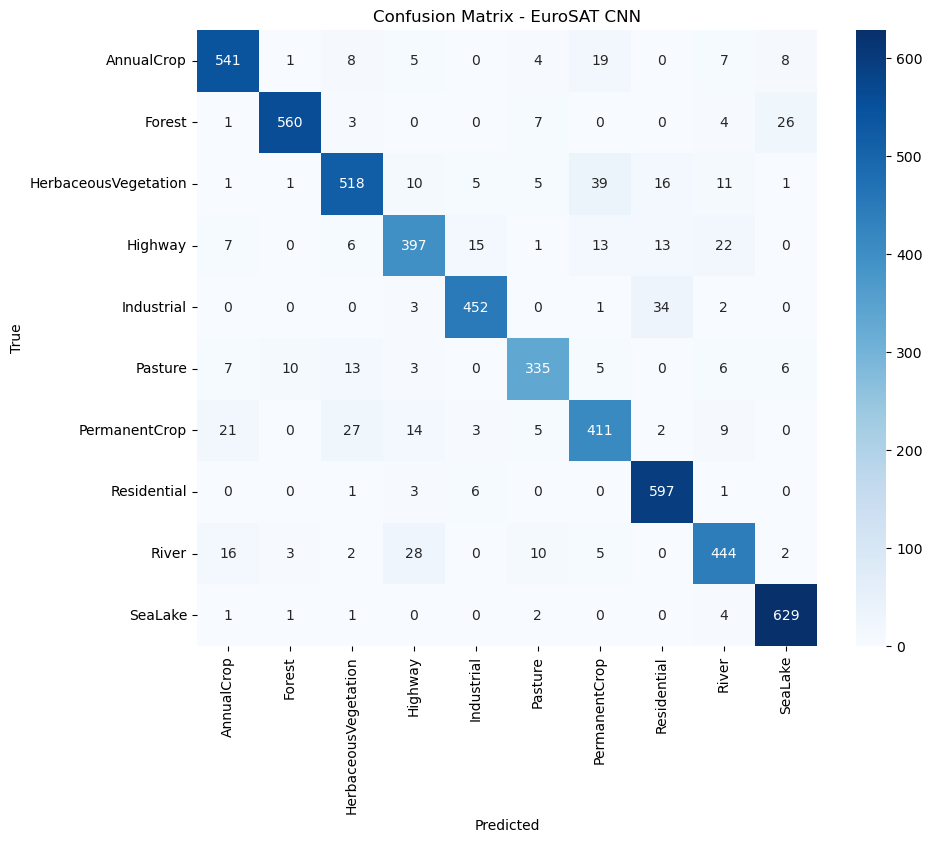

In [33]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - EuroSAT CNN")
plt.show()

In [34]:
print(classification_report(y_true, y_pred, target_names=dataset.classes))

                      precision    recall  f1-score   support

          AnnualCrop       0.91      0.91      0.91       593
              Forest       0.97      0.93      0.95       601
HerbaceousVegetation       0.89      0.85      0.87       607
             Highway       0.86      0.84      0.85       474
          Industrial       0.94      0.92      0.93       492
             Pasture       0.91      0.87      0.89       385
       PermanentCrop       0.83      0.84      0.83       492
         Residential       0.90      0.98      0.94       608
               River       0.87      0.87      0.87       510
             SeaLake       0.94      0.99      0.96       638

            accuracy                           0.90      5400
           macro avg       0.90      0.90      0.90      5400
        weighted avg       0.90      0.90      0.90      5400



In [29]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import rasterio

In [33]:
sentinel_path = "/Users/monicachaganti/Desktop/ML models for Earth observation/Sentinal-2/sentinel_2"
print(os.listdir(sentinel_path))

['.DS_Store', 'ds']


In [63]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
import rasterio

class SentinelDataset(Dataset):
    def __init__(self, root):
        self.root = root

        self.classes = sorted([
            d for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d))
        ])

        self.images = []
        self.labels = []

        for idx, cls in enumerate(self.classes):
            class_path = os.path.join(root, cls)

            for r, _, files in os.walk(class_path):
                for file in files:
                    if file.lower().endswith((".tif", ".tiff")):
                        self.images.append(os.path.join(r, file))
                        self.labels.append(idx)

        print("Total images loaded:", len(self.images))
        print("Classes:", self.classes)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = self.images[idx]
        label = self.labels[idx]

        with rasterio.open(path) as src:
            img = src.read()

        # keep RGB only
        img = img[:3, :, :]

        # HWC format
        img = np.transpose(img, (1, 2, 0))

        # convert to float and normalize
        img = img.astype(np.float32) / 255.0

        # to tensor (still HWC here)
        img = torch.from_numpy(img)

        # convert to CHW for PyTorch
        img = img.permute(2, 0, 1)

        return img, label

In [65]:
sentinel_dataset = SentinelDataset(sentinel_path)

Total images loaded: 27000
Classes: ['ds']


In [75]:
def __getitem__(self, idx):
    path = self.images[idx]
    label = self.labels[idx]

    with rasterio.open(path) as src:
        img = src.read()  

    img = img[:3] 

    img = np.transpose(img, (1, 2, 0)) 

    img = torch.from_numpy(img.astype(np.float32))  

    img = img.permute(2, 0, 1) / 10000.0  

    return img, label

In [77]:
img, label = sentinel_dataset[0]

print(img.shape)
print(img.dtype)
print(img.min(), img.max())
print(label)

torch.Size([3, 64, 64])
torch.float32
tensor(2.1686) tensor(4.6078)
0


In [85]:
from torch.utils.data import DataLoader

loader = DataLoader(sentinel_dataset, batch_size=32, shuffle=False)

In [93]:
import torch
import torch.nn as nn

In [95]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [97]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN(num_classes=10)
model = model.to(device)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=128, out_features=10, bias=True)
)


In [107]:
eurosat_path = "/Users/monicachaganti/Desktop/ML models for Earth observation/EuroSat/EuroSAT"

In [109]:
from torchvision import datasets, transforms

In [111]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [113]:
eurosat_dataset = datasets.ImageFolder(
    root=eurosat_path,
    transform=transform
)

print(len(eurosat_dataset))
print(eurosat_dataset.classes)

27000
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [115]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(eurosat_dataset))
test_size = len(eurosat_dataset) - train_size

train_dataset, test_dataset = random_split(
    eurosat_dataset,
    [train_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [117]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [119]:
epochs = 5

model.train()

for epoch in range(epochs):
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

Epoch 1, Loss: 1.4387123354276021
Epoch 2, Loss: 0.9951527094841004
Epoch 3, Loss: 0.8440149839277621
Epoch 4, Loss: 0.7518518180758865
Epoch 5, Loss: 0.714063349476567


In [121]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("EuroSAT Accuracy:", 100 * correct / total)

EuroSAT Accuracy: 74.37037037037037


In [123]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [125]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [127]:
sentinel_path = "/Users/monicachaganti/Desktop/ML models for Earth observation/Sentinal-2/sentinel_2"

sentinel_dataset = datasets.ImageFolder(
    root=sentinel_path,
    transform=transform
)

print(len(sentinel_dataset))
print(sentinel_dataset.classes)

27000
['ds']


In [129]:
sentinel_loader = DataLoader(
    sentinel_dataset,
    batch_size=32,
    shuffle=False
)

In [133]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset

In [135]:
class SafeSentinelDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.images = []
        self.labels = []
        self.classes = sorted(os.listdir(root))

        for label, cls in enumerate(self.classes):
            class_path = os.path.join(root, cls)

            if not os.path.isdir(class_path):
                continue

            for file in os.listdir(class_path):
                if file.lower().endswith((".jpg", ".png", ".jpeg")):
                    self.images.append(os.path.join(class_path, file))
                    self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [137]:
sentinel_dataset = SafeSentinelDataset(
    root="/Users/monicachaganti/Desktop/ML models for Earth observation/Sentinal-2/sentinel_2",
    transform=transform
)

In [139]:
sentinel_loader = DataLoader(sentinel_dataset, batch_size=32, shuffle=False)

In [141]:
model.eval()

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=128, out_features=10, bias=True)
)

In [145]:
import os
import torch
from torch.utils.data import Dataset
import rasterio
import numpy as np

In [147]:
class SentinelDataset(Dataset):
    def __init__(self, root):
        self.images = []
        self.labels = []
        self.classes = sorted(os.listdir(root))

        for label, cls in enumerate(self.classes):
            class_path = os.path.join(root, cls)

            if not os.path.isdir(class_path):
                continue

            for file in os.listdir(class_path):
                if file.endswith(".tif"):
                    self.images.append(os.path.join(class_path, file))
                    self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = self.images[idx]
        label = self.labels[idx]

        with rasterio.open(path) as src:
            img = src.read()

        # take first 3 bands (RGB approximation)
        img = img[:3]

        img = np.transpose(img, (1, 2, 0)).astype(np.float32)

        # normalize safely
        img = img / np.max(img)

        img = torch.tensor(img).permute(2, 0, 1)

        return img, label

In [155]:
sentinel_path = "/Users/monicachaganti/Desktop/ML models for Earth observation/Sentinal-2/sentinel_2/ds/images/remote_sensing/otherDatasets/sentinel_2/tif"

In [157]:
sentinel_dataset = SentinelDataset(sentinel_path)

In [159]:
print("Samples:", len(sentinel_dataset))
print("Classes:", sentinel_dataset.classes)

Samples: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [167]:
print(len(sentinel_dataset))

27000


In [169]:
from torch.utils.data import DataLoader

sentinel_loader = DataLoader(
    sentinel_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [171]:
print(len(sentinel_loader.dataset))

27000


In [173]:
images, labels = next(iter(sentinel_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 64, 64]) torch.Size([32])


In [175]:
images, labels = next(iter(sentinel_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 64, 64]) torch.Size([32])


In [177]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in sentinel_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Sentinel-2 Accuracy:", 100 * correct / total)

Sentinel-2 Accuracy: 12.777777777777779
